# Insurance Policy Sales Analysis

This project explores an insurance policy dataset using Python.  
The analysis focuses on sales trends over time, product performance, city-level distribution, payment methods, and premium-based business insights.

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import plotly.express as px
import warnings
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/insurance_sample.csv")
df

,Date,Product,Gross_Premium,Total_Incl_VAT,City,Payment_Status,Payment_Method,Policy_Start_Date,Policy_Term,Policy_Duration_Days,Policy_End_Date,Customer_ID
0,2025-02-02,Travel,854.0,1007.72,Los Angeles,Pending,Online,2025-02-02,1Y,365,2026-02-01,CUST0001
1,2025-10-09,Travel,921.0,1086.78,Los Angeles,Paid,Card,2025-10-09,1Y,365,2026-10-08,CUST0002
2,2025-08-27,Medical,858.0,1012.44,New York,Paid,Online,2025-08-27,1M,30,2025-09-25,CUST0003
3,2025-06-09,Motor,771.0,909.78,Chicago,Paid,Online,2025-06-09,1Y,365,2026-06-08,CUST0004
4,2025-06-07,Medical,822.0,969.96,Los Angeles,Paid,Cash,2025-06-07,1Y,365,2026-06-06,CUST0005
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2025-01-01,Medical,787.0,928.66,Chicago,Pending,Bank Transfer,2025-01-01,1Y,365,2025-12-31,CUST1996
1996,2025-07-21,Medical,886.0,1045.48,Atlanta,Paid,Card,2025-07-21,1Y,365,2026-07-20,CUST1997
1997,2025-12-28,Medical,715.0,843.70,Chicago,Paid,Online,2025-12-28,1Y,365,2026-12-27,CUST1998
1998,2025-04-13,Travel,855.0,1008.90,New York,Paid,Bank Transfer,2025-04-13,1Y,365,2026-04-12,CUST1999


In [5]:

# Date columns
date_cols = ["Date", "Policy_Start_Date", "Policy_End_Date"]

# Convert to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Main Date column features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()
df["Quarter"] = df["Date"].dt.quarter
df["Week_of_Year"] = df["Date"].dt.isocalendar().week.astype(int)

# Policy start date features
df["Policy_Start_Year"] = df["Policy_Start_Date"].dt.year
df["Policy_Start_Month"] = df["Policy_Start_Date"].dt.month
df["Policy_Start_Weekday"] = df["Policy_Start_Date"].dt.day_name()
df["Policy_Start_Quarter"] = df["Policy_Start_Date"].dt.quarter

# Policy end date features
df["Policy_End_Year"] = df["Policy_End_Date"].dt.year
df["Policy_End_Month"] = df["Policy_End_Date"].dt.month
df["Policy_End_Weekday"] = df["Policy_End_Date"].dt.day_name()
df["Policy_End_Quarter"] = df["Policy_End_Date"].dt.quarter

In [6]:
df.head()

,Date,Product,Gross_Premium,Total_Incl_VAT,City,Payment_Status,Payment_Method,Policy_Start_Date,Policy_Term,Policy_Duration_Days,...,Quarter,Week_of_Year,Policy_Start_Year,Policy_Start_Month,Policy_Start_Weekday,Policy_Start_Quarter,Policy_End_Year,Policy_End_Month,Policy_End_Weekday,Policy_End_Quarter
0,2025-02-02,Travel,854.0,1007.72,Los Angeles,Pending,Online,2025-02-02,1Y,365,...,1,5,2025,2,Sunday,1,2026,2,Sunday,1
1,2025-10-09,Travel,921.0,1086.78,Los Angeles,Paid,Card,2025-10-09,1Y,365,...,4,41,2025,10,Thursday,4,2026,10,Thursday,4
2,2025-08-27,Medical,858.0,1012.44,New York,Paid,Online,2025-08-27,1M,30,...,3,35,2025,8,Wednesday,3,2025,9,Thursday,3
3,2025-06-09,Motor,771.0,909.78,Chicago,Paid,Online,2025-06-09,1Y,365,...,2,24,2025,6,Monday,2,2026,6,Monday,2
4,2025-06-07,Medical,822.0,969.96,Los Angeles,Paid,Cash,2025-06-07,1Y,365,...,2,23,2025,6,Saturday,2,2026,6,Saturday,2


In [13]:
df.columns

Index(['Date', 'Product', 'Gross_Premium', 'Total_Incl_VAT', 'City',
       'Payment_Status', 'Payment_Method', 'Policy_Start_Date', 'Policy_Term',
       'Policy_Duration_Days', 'Policy_End_Date', 'Customer_ID', 'Year',
       'Month', 'Month_Name', 'Day', 'Weekday', 'Quarter', 'Week_of_Year',
       'Policy_Start_Year', 'Policy_Start_Month', 'Policy_Start_Weekday',
       'Policy_Start_Quarter', 'Policy_End_Year', 'Policy_End_Month',
       'Policy_End_Weekday', 'Policy_End_Quarter'],
      dtype='object')

=== Number of Policies by Year ===
Policy_Start_Year
2025    2000
dtype: int64


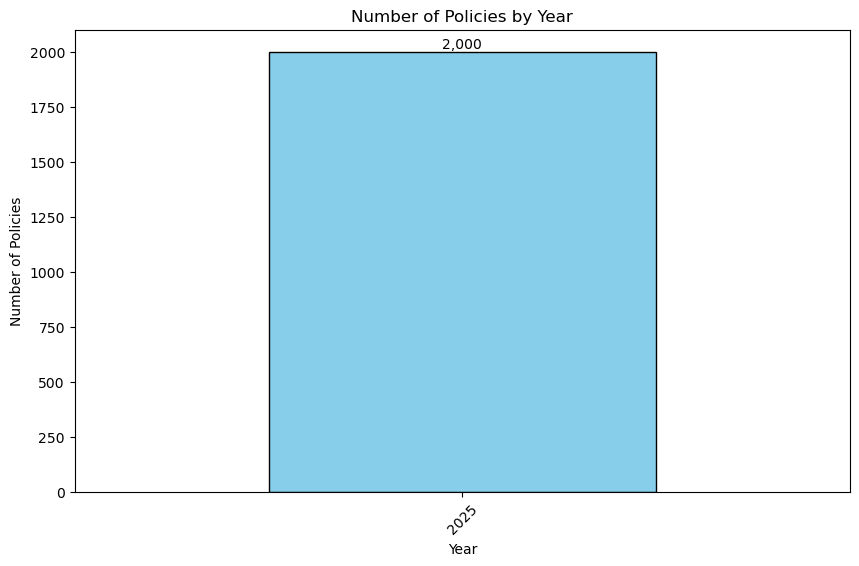

In [7]:

import matplotlib.pyplot as plt

# Number of policies by policy start year
yearly_counts = df.groupby("Policy_Start_Year").size()

print("=== Number of Policies by Year ===")
print(yearly_counts)

# Visualization
plt.figure(figsize=(10, 6))
ax = yearly_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Number of Policies by Year")
plt.xlabel("Year")
plt.ylabel("Number of Policies")
plt.xticks(rotation=45)

# Add value labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

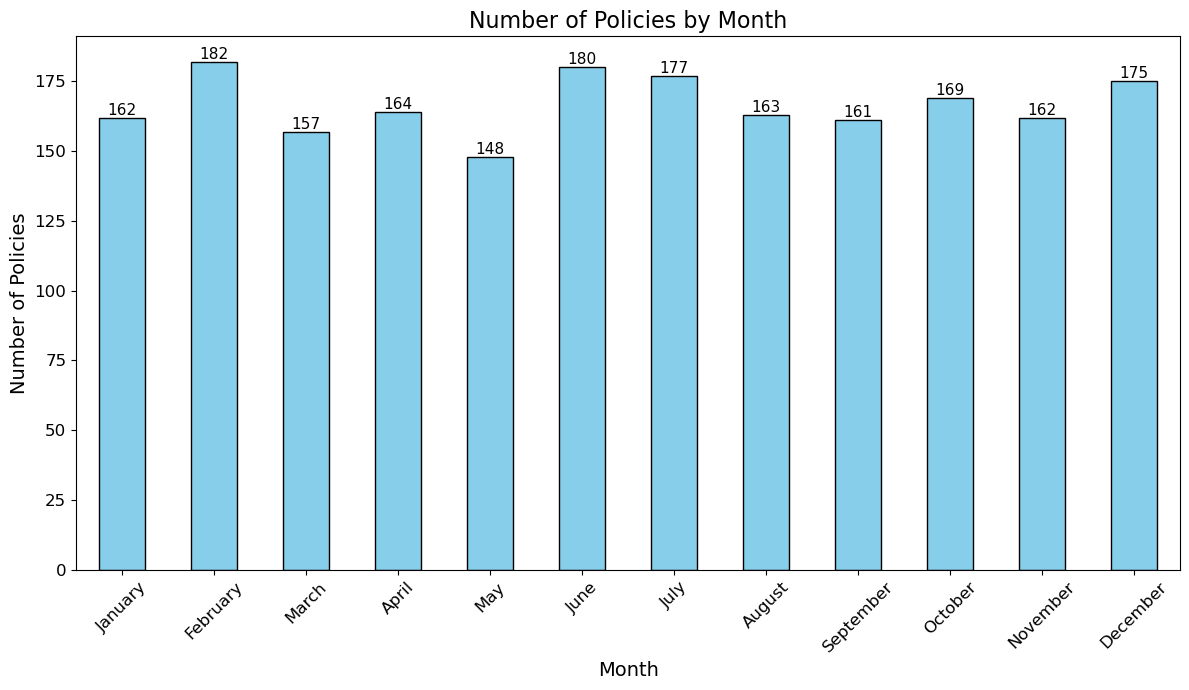

In [9]:
import calendar
import matplotlib.pyplot as plt

# Number of policies by month
monthly_counts = (
    df.groupby("Policy_Start_Month")
    .size()
    .sort_index()
)

# Rename index with month names
monthly_counts.index = [calendar.month_name[m] for m in monthly_counts.index]

# Visualization
plt.figure(figsize=(12, 7))
ax = monthly_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Number of Policies by Month", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Policies", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

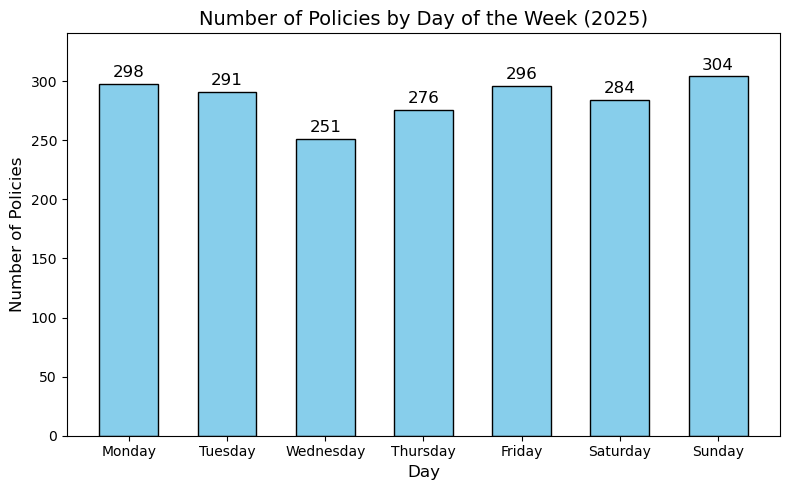

In [15]:
import matplotlib.pyplot as plt

def plot_policies_by_weekday(year=None):
    # Filter by year if a specific year is provided
    if year is not None:
        dff = df[df["Policy_Start_Year"] == year]
        title_suffix = f" ({year})"
    else:
        dff = df
        title_suffix = " (All Years)"

    # Ordered weekdays
    ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    # Count policies by weekday
    counts = (
        dff.groupby("Policy_Start_Weekday")
        .size()
        .reindex(ordered_days)
        .fillna(0)
    )

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(counts.index, counts.values, edgecolor="black", color="skyblue", width=0.6)

    ax.set_title("Number of Policies by Day of the Week" + title_suffix, fontsize=14)
    ax.set_xlabel("Day", fontsize=12)
    ax.set_ylabel("Number of Policies", fontsize=12)

    # Add labels above bars
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max(counts.values) * 0.01 if max(counts.values) > 0 else 0.1),
            f"{int(val):,}",
            ha="center",
            va="bottom",
            fontsize=12
        )

    ax.set_ylim(0, max(counts.values) * 1.12 if max(counts.values) > 0 else 1)
    ax.yaxis.get_major_locator().set_params(integer=True)

    plt.tight_layout()
    plt.show()


# Example: only for 2025
plot_policies_by_weekday(2025)

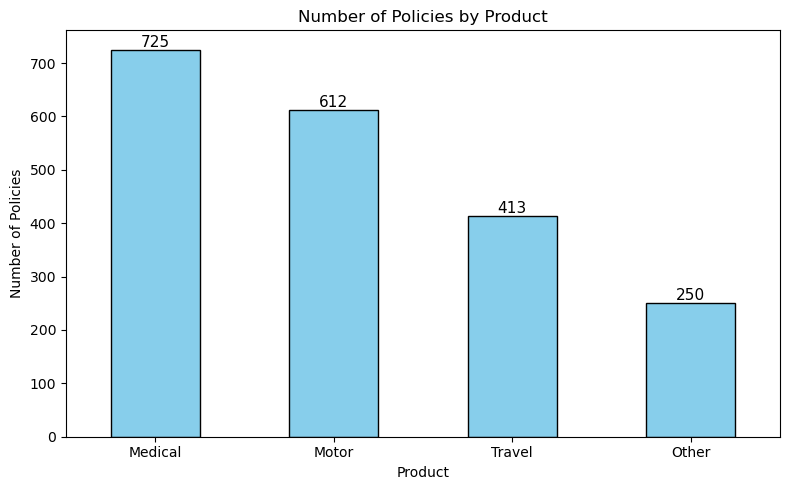

In [16]:
import matplotlib.pyplot as plt

# Number of policies by product
product_counts = df["Product"].value_counts()

plt.figure(figsize=(8, 5))
ax = product_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Number of Policies by Product")
plt.xlabel("Product")
plt.ylabel("Number of Policies")
plt.xticks(rotation=0)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

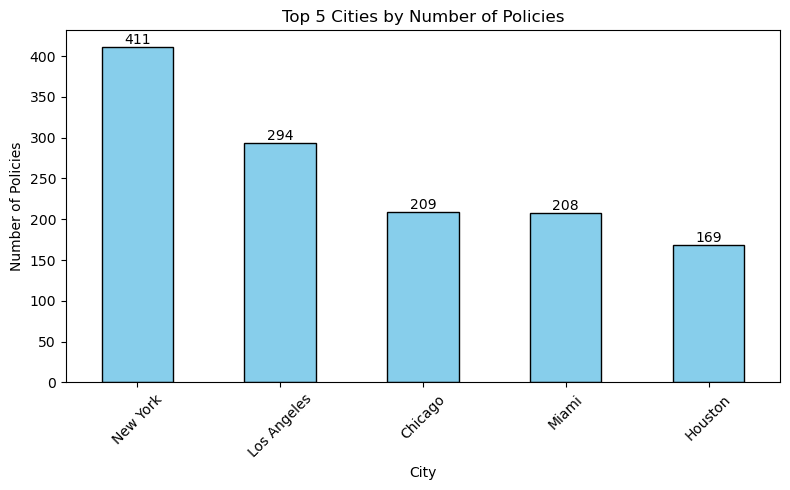

In [19]:
top_5_cities = df["City"].value_counts().head(5)

plt.figure(figsize=(8, 5))
ax = top_5_cities.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Top 5 Cities by Number of Policies")
plt.xlabel("City")
plt.ylabel("Number of Policies")
plt.xticks(rotation=45)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

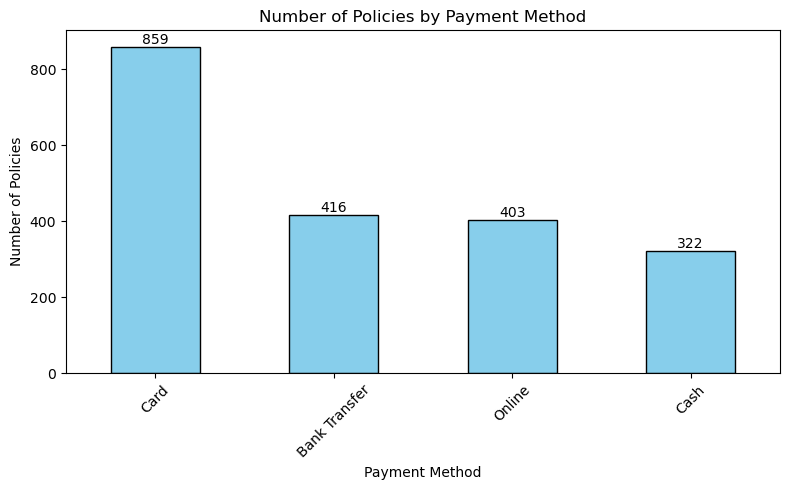

In [20]:
import matplotlib.pyplot as plt

# Number of policies by payment method
payment_method_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8, 5))
ax = payment_method_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Number of Policies by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Policies")
plt.xticks(rotation=45)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

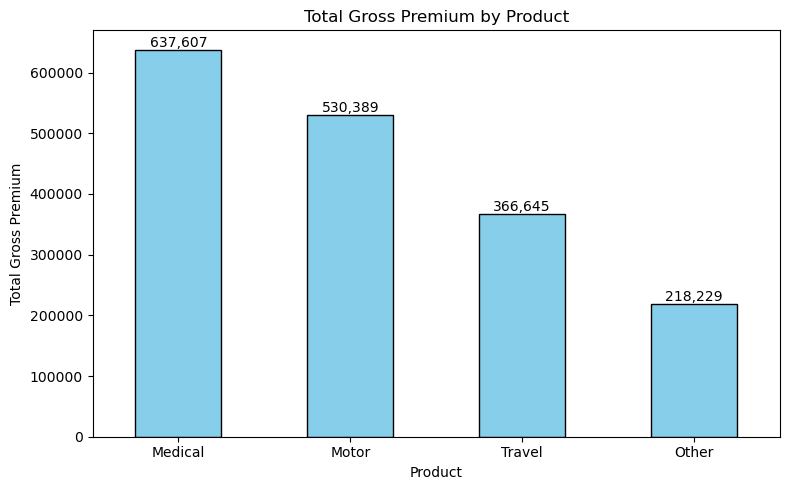

In [21]:
import matplotlib.pyplot as plt

gross_premium_product_sum = df.groupby("Product")["Gross_Premium"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = gross_premium_product_sum.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Total Gross Premium by Product")
plt.xlabel("Product")
plt.ylabel("Total Gross Premium")
plt.xticks(rotation=0)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [22]:
total_gross_premium = df["Gross_Premium"].sum()
total_incl_vat = df["Total_Incl_VAT"].sum()

print("=== Total Revenue Summary ===")
print(f"Total Gross Premium: {total_gross_premium:,.2f}")
print(f"Total Revenue Including VAT: {total_incl_vat:,.2f}")

=== Total Revenue Summary ===
Total Gross Premium: 1,752,870.00
Total Revenue Including VAT: 2,068,386.60
